In [210]:
import pandas as pd
df = pd.read_csv("/content/BankChurners.csv")
df.head()
df.shape

(10127, 23)

In [211]:
df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')

In [212]:
df.drop(columns=["CLIENTNUM","Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1","Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2"],inplace=True)
df.shape

(10127, 20)

In [213]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.isna().sum()

,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0
Total_Relationship_Count,0


In [214]:
Y.unique()

array(['Existing Customer', 'Attrited Customer'], dtype=object)

In [215]:
Y = Y.map({"Existing Customer":0,"Attrited Customer":1})
Y.unique()

array([0, 1])

In [216]:
X = df.drop(columns=["Attrition_Flag"])
Y = df["Attrition_Flag"]
X.shape, Y.shape

((10127, 19), (10127,))

In [217]:
Y.value_counts(normalize=True)

,proportion
Attrition_Flag,
Existing Customer,0.83934
Attrited Customer,0.16066


In [218]:
X_ohe = pd.get_dummies(X)
X_ohe.shape

(10127, 37)

In [219]:
cont_col = X.columns[X.nunique()>15]


In [220]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X_ohe,Y,test_size=0.3,random_state=7,stratify=Y)
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((7088, 37), (3039, 37), (7088,), (3039,))

In [221]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train[cont_col] = sc.fit_transform(X_train[cont_col])
X_test[cont_col] = sc.transform(X_test[cont_col])

In [222]:
X_train[cont_col].mean()

,0
Customer_Age,-1.323246e-16
Months_on_book,-1.243049e-16
Credit_Limit,1.152828e-16
Total_Revolving_Bal,-1.273123e-16
Avg_Open_To_Buy,-5.914506e-17
Total_Amt_Chng_Q4_Q1,-2.917155e-16
Total_Trans_Amt,-3.007376e-17
Total_Trans_Ct,-1.924721e-16
Total_Ct_Chng_Q4_Q1,-5.714015e-17
Avg_Utilization_Ratio,-4.811802e-17


In [223]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95,random_state=7) #all possible components
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
X_train_pca.shape, X_test_pca.shape


((7088, 19), (3039, 19))

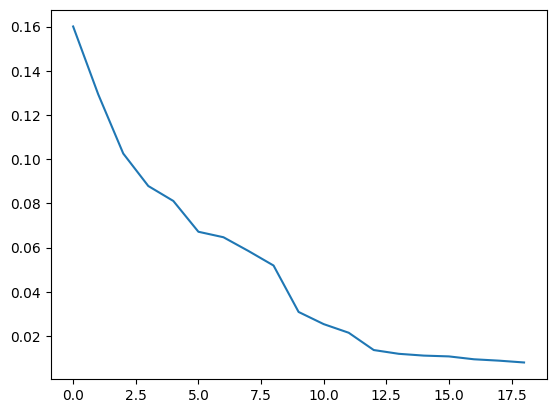

In [224]:
import matplotlib.pyplot as plt
plt.plot(range(len(pca.components_)),pca.explained_variance_ratio_)

In [225]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
rfe = RFE(LogisticRegression(random_state=7),verbose=2)
rfe.fit_transform(X_train,Y_train)
print(rfe.ranking_)


Fitting estimator with 37 features.
Fitting estimator with 36 features.
Fitting estimator with 35 features.
Fitting estimator with 34 features.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting estimator with 33 features.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting estimator with 32 features.
Fitting estimator with 31 features.
Fitting estimator with 30 features.
Fitting estimator with 29 features.


...

Fitting estimator with 28 features.
Fitting estimator with 27 features.
Fitting estimator with 26 features.
Fitting estimator with 25 features.
Fitting estimator with 24 features.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting estimator with 23 features.
Fitting estimator with 22 features.
Fitting estimator with 21 features.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting estimator with 20 features.
Fitting estimator with 19 features.
[20  5 16  1  1  1  2  1 14 10  1  1  1 11  1  1  1  1 13 12  1 15 17  3
  1  4 18  1  1  9  1  8  6  1  1  7 19]


In [226]:
for col,rank in zip(X_train.columns,rfe.ranking_):
  print(col,rank)

Customer_Age 20
Dependent_count 5
Months_on_book 16
Total_Relationship_Count 1
Months_Inactive_12_mon 1
Contacts_Count_12_mon 1
Credit_Limit 2
Total_Revolving_Bal 1
Avg_Open_To_Buy 14
Total_Amt_Chng_Q4_Q1 10
Total_Trans_Amt 1
Total_Trans_Ct 1
Total_Ct_Chng_Q4_Q1 1
Avg_Utilization_Ratio 11
Gender_F 1
Gender_M 1
Education_Level_College 1
Education_Level_Doctorate 1
Education_Level_Graduate 13
Education_Level_High School 12
Education_Level_Post-Graduate 1
Education_Level_Uneducated 15
Education_Level_Unknown 17
Marital_Status_Divorced 3
Marital_Status_Married 1
Marital_Status_Single 4
Marital_Status_Unknown 18
Income_Category_$120K + 1
Income_Category_$40K - $60K 1
Income_Category_$60K - $80K 9
Income_Category_$80K - $120K 1
Income_Category_Less than $40K 8
Income_Category_Unknown 6
Card_Category_Blue 1
Card_Category_Gold 1
Card_Category_Platinum 7
Card_Category_Silver 19


In [227]:
X_train.columns[rfe.ranking_ == 1]

Index(['Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Total_Revolving_Bal', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Gender_F', 'Gender_M',
       'Education_Level_College', 'Education_Level_Doctorate',
       'Education_Level_Post-Graduate', 'Marital_Status_Married',
       'Income_Category_$120K +', 'Income_Category_$40K - $60K',
       'Income_Category_$80K - $120K', 'Card_Category_Blue',
       'Card_Category_Gold'],
      dtype='object')

In [228]:
selected_cols = X_train.columns[rfe.ranking_ == 1]
selected_cols

Index(['Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Total_Revolving_Bal', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Gender_F', 'Gender_M',
       'Education_Level_College', 'Education_Level_Doctorate',
       'Education_Level_Post-Graduate', 'Marital_Status_Married',
       'Income_Category_$120K +', 'Income_Category_$40K - $60K',
       'Income_Category_$80K - $120K', 'Card_Category_Blue',
       'Card_Category_Gold'],
      dtype='object')

In [229]:
X_train_rfe = X_train.loc[:,selected_cols]
X_test_rfe = X_test.loc[:,selected_cols]
X_train_rfe.shape, X_test_rfe.shape

((7088, 18), (3039, 18))

In [230]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion = "gini",random_state=7,class_weight="balanced",)
dt.fit(X_train,Y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=7)

In [231]:
fi = zip(X_train.columns,dt.feature_importances_)
for col,imp in sorted(fi,key=(lambda x:x[1]),reverse=True):
  print(col,imp)

Total_Trans_Ct 0.4300525186093622
Total_Trans_Amt 0.18805300371891823
Total_Revolving_Bal 0.09778747289682556
Total_Ct_Chng_Q4_Q1 0.08158874027307755
Total_Relationship_Count 0.05967360529318638
Total_Amt_Chng_Q4_Q1 0.03698245018384902
Customer_Age 0.024760675499153995
Contacts_Count_12_mon 0.013061546132834985
Credit_Limit 0.01303504069700903
Months_on_book 0.009775725214064253
Avg_Open_To_Buy 0.008234684722549238
Months_Inactive_12_mon 0.005882091313035296
Dependent_count 0.005831651425530805
Income_Category_$60K - $80K 0.003377776244031145
Avg_Utilization_Ratio 0.0025264505461782705
Education_Level_Graduate 0.0020019087137868982
Marital_Status_Single 0.0019413778787708649
Marital_Status_Married 0.001890210294356557
Education_Level_College 0.0018332886568240784
Gender_F 0.0016647951184587213
Education_Level_High School 0.0015251907069466254
Income_Category_$120K + 0.0013996181896700974
Card_Category_Silver 0.0013063930837907503
Income_Category_$40K - $60K 0.001256441605754893
Gender_

In [232]:
selected_cols = X_train.columns[dt.feature_importances_ > dt.feature_importances_.mean()]
X_train_dt = X_train.loc[:,selected_cols]
X_test_dt = X_test.loc[:,selected_cols]
X_train_dt.shape, X_test_dt.shape

((7088, 6), (3039, 6))

In [233]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion = "entropy",random_state=7,class_weight="balanced")
dt.fit(X_train,Y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       random_state=7)

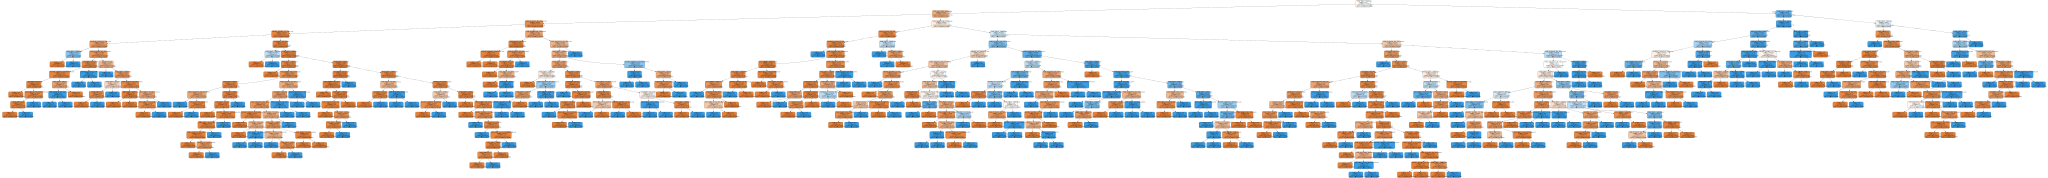

In [234]:
from sklearn.tree import export_graphviz
import graphviz

# Export the decision tree to a DOT format
dot_data = export_graphviz(dt, out_file=None,
                           feature_names=X_train.columns,
                           class_names=['Existing Customer', 'Attrited Customer'],
                           filled=True, rounded=True,
                           special_characters=True)

# Render the DOT graph into a visual representation (e.g., PNG)
graph = graphviz.Source(dot_data)

# Display the graph. Note: For large trees, this might be very dense.
# You might want to save it to a file if it's too large to display directly.
display(graph)

Please note that for very deep or complex trees, the visualization might be hard to read directly in the notebook due to its size. You might need to save it to a file (e.g., PDF, PNG) for better viewing, or zoom in significantly.

In [235]:
fi = zip(X_train.columns,dt.feature_importances_)
for col,imp in sorted(fi,key=(lambda x:x[1]),reverse=True):
  print(col,imp)

Total_Trans_Ct 0.3754861929228929
Total_Trans_Amt 0.20644906702066843
Total_Revolving_Bal 0.10873091937568172
Total_Ct_Chng_Q4_Q1 0.07096030302008553
Total_Relationship_Count 0.05927592678299341
Total_Amt_Chng_Q4_Q1 0.03648672747697706
Customer_Age 0.026588810267558088
Months_on_book 0.015830966750153445
Contacts_Count_12_mon 0.014936580846100334
Credit_Limit 0.014575935259401962
Avg_Open_To_Buy 0.014103621982177976
Months_Inactive_12_mon 0.011218185126524224
Education_Level_Doctorate 0.006070583211439912
Avg_Utilization_Ratio 0.005339471658731844
Dependent_count 0.004764452610936663
Gender_M 0.0037174523014184956
Income_Category_$40K - $60K 0.0034750720861953786
Education_Level_High School 0.0030504743169080663
Gender_F 0.0026309908573900914
Income_Category_Unknown 0.0021511207196661638
Card_Category_Blue 0.0020303705019169382
Card_Category_Silver 0.0019762713155271755
Education_Level_Graduate 0.0016927259431524283
Income_Category_$60K - $80K 0.0014956087470505554
Marital_Status_Singl